# STORM RHT Synapse Figures

Reproducible figures for **Figure 4** (P8, pre-eye-opening) and **Figure S6**
(Adult) of the melanopsin / RHT synapse STORM analysis.

This notebook reads `data/Table_S5_STORM_synapse_information.xlsx` and produces:

1. **Synapse density** dot plots — individual biological replicates
   (N = 6 per genotype) with the group **mean ± S.D.** overlaid as error bars.
   Het = black, KO = red.
2. **Volume & Intensity** violin + box-and-whisker plots for **VGluT2**,
   **Bassoon**, and **Homer1**. Boxes show the median and interquartile range;
   whiskers extend to 1.5× IQR; the violin outline is a kernel-density estimate.

The plotting functions live in `storm_figures.py` and mirror the MATLAB code in
`matlab/` one-to-one, so the same figures can be regenerated in either language.


In [1]:
import matplotlib.pyplot as plt
import storm_figures as sf

plt.rcParams.update({"font.family": "sans-serif", "font.size": 9})

data = sf.load_storm_data("data/STORM_raw_spreadsheet.xlsx")
{k: (v.shape if hasattr(v, "shape") else v) for k, v in data.items()}


{'density': (24, 6),
 'VGluT2': (43989, 6),
 'Bassoon': (42197, 6),
 'Homer': (45900, 6)}

## Quick look at the data

The density sheet has one row per biological replicate; the volume/intensity
sheets have one row per detected synaptic cluster.

In [2]:
data["density"].head()

,Sample_ID,Age,Genotype,Replicate,Channel,Density
0,P8_Het_A,P8,Het,1,VGluT2,0.025956
1,P8_Het_B,P8,Het,2,VGluT2,0.028687
2,P8_Het_C,P8,Het,3,VGluT2,0.033451
3,P8_Het_D,P8,Het,4,VGluT2,0.027306
4,P8_Het_E,P8,Het,5,VGluT2,0.028889


In [3]:
# Per-group mean +/- S.D. (matches the values quoted in the figure legends)
d = data["density"]
(d[d["Channel"] == "VGluT2"]
   .groupby(["Age", "Genotype"])["Density"]
   .agg(N="count", mean="mean", SD="std")
   .round(4))


N    mean      SD
Age   Genotype                   
Adult Het       6  0.0443  0.0073
      KO        6  0.0454  0.0063
P8    Het       6  0.0299  0.0036
      KO        6  0.0227  0.0018

## Figure S6A — Adult synapse density

No significant difference between Opn4-KO and Opn4-Het controls
(Het 0.044 ± 0.007; KO 0.045 ± 0.003).

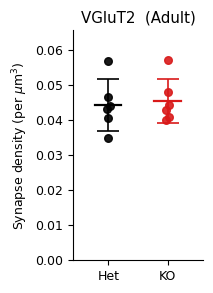

In [4]:
fig = sf.plot_density(data, "Adult")
fig.savefig("output/FigS6A_density_Adult.png", dpi=300, bbox_inches="tight")
fig.savefig("output/FigS6A_density_Adult.pdf", bbox_inches="tight")
plt.show()


## Figure S6C — Adult volume & intensity distributions

Volume (µm³) and intensity (A.U.) for the three synaptic proteins across
N = 6 Het (12,061 synapses) and N = 6 KO (11,041 synapses). No significant
differences between genotypes.

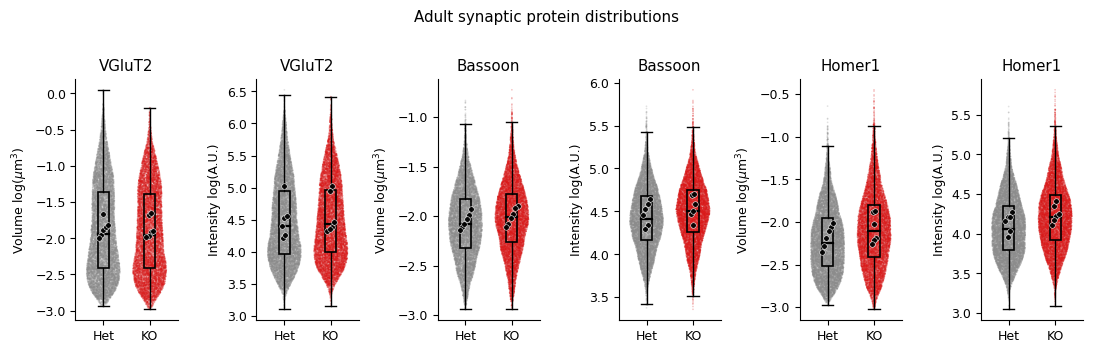

In [5]:
fig = sf.plot_volume_intensity(data, "Adult")
fig.savefig("output/FigS6C_volint_Adult.png", dpi=300, bbox_inches="tight")
fig.savefig("output/FigS6C_volint_Adult.pdf", bbox_inches="tight")
plt.show()


## Figure 4B — P8 synapse density

Significantly reduced density in Opn4-KO vs Opn4-Het
(Het 0.030 ± 0.004; KO 0.023 ± 0.002; Cohen's d 2.5; ***p < 0.001, t-test).

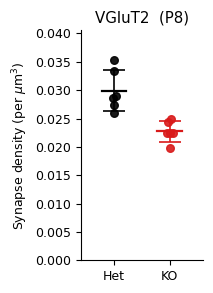

In [6]:
fig = sf.plot_density(data, "P8")
fig.savefig("output/Fig4B_density_P8.png", dpi=300, bbox_inches="tight")
fig.savefig("output/Fig4B_density_P8.pdf", bbox_inches="tight")
plt.show()


## Figure 4D — P8 volume & intensity distributions

Volume and intensity for VGluT2, Bassoon, and Homer1 across N = 6 Het
(10,814 synapses) and N = 6 KO (10,013 synapses).

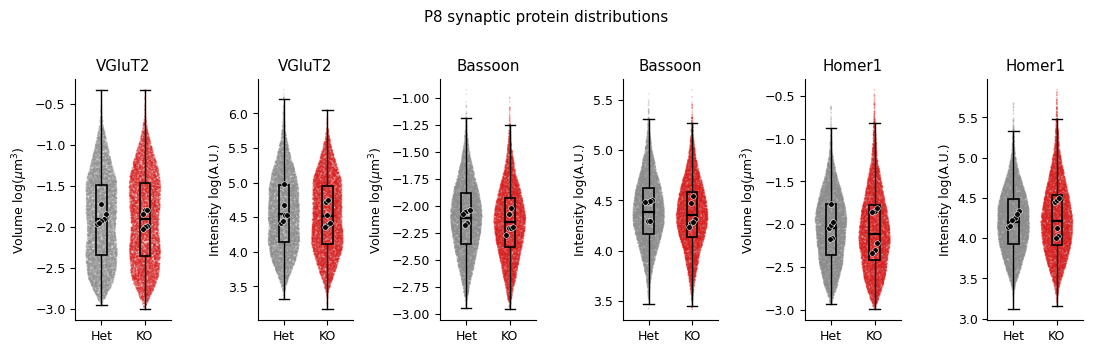

In [7]:
fig = sf.plot_volume_intensity(data, "P8")
fig.savefig("output/Fig4D_volint_P8.png", dpi=300, bbox_inches="tight")
fig.savefig("output/Fig4D_volint_P8.pdf", bbox_inches="tight")
plt.show()
